<a href="https://colab.research.google.com/github/AndrePellegrini/POS_TECH_RM373717/blob/main/Case_NPS_Preditivo_Tech_Challenge_Andr%C3%A9_Pellegrini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tecah Challenge Fase 1 - Case NPS Preditivo <br/>
Nome: André Afonso Pellegrini <br/>
RM373717



## Base de dados utilizado e o Problema de Negócio <br/>
desafio_nps_fase_1.csv  <br/> <br/>
Principal pergunta: quais fatores operacionais realmente influenciam a satisfação do cliente e como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da aplicação da pesquisa de NPS? <br/> <br/>
Desafios encontrados (definição do problema):<br/>
- Identificar quais fatores operacionais estão relacionados à satisfação
- E usar isso para antecipar e melhorar a experiência do cliente


## Trazendo a Lib e a Base de Dados

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from pandas.core.tools.datetimes import Scalar

In [2]:
df = pd.read_csv('desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## Conhecendo a base de dados e Analisando a qualidade dos dados

In [3]:
df.shape

(2500, 19)

Temos 2500 linhas e 19 colunas

In [4]:
df.dtypes

,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64


Dicionário de dados: <br/>
- customer_id: Identificador único do cliente.
- order_id: Identificador único do pedido.
- customer_age: Idade do cliente.
- customer_region: Região geográfica do cliente.
- customer_tenure_months: Tempo de relacionamento do cliente com a empresa (em meses).
- order_value: Valor total do pedido.
- items_quantity: Quantidade de itens no pedido.
- discount_value: Valor de desconto aplicado ao pedido.
- payment_installments: Número de parcelas do pagamento.
- delivery_time_days: Tempo total de entrega (em dias).
- delivery_delay_days: Quantidade de dias de atraso na entrega.
- freight_value: Valor do frete.
- delivery_attempts: Número de tentativas de entrega.
- customer_service_contacts: Número de contatos do cliente com o atendimento.
- resolution_time_days: Tempo para resolução de problemas (em dias).
- complaints_count: Número de reclamações registradas pelo cliente.
- repeat_purchase_30d: Indica se houve recompra em até 30 dias após o pedido (0 = não, 1 = sim).
- csat_internal_score: Score interno de satisfação do cliente.
- nps_score: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra.

In [5]:
df.isnull().sum().sum()

np.int64(0)

Avaliando se existe valores nulos. No caso dessa BD não existe.

## Dados que serão utilizados <br/>
Vamos definir algumas colunas na qual podemos interpretar que afeta mais o NPS para entender o comportamento da nota e propor soluções em cima dos dados analisados

Vamos começar definindo as colunas <br/>
- delivery_delay_days: Quantidade de dias de atraso na entrega.
- customer_service_contacts: Número de contatos do cliente com o atendimento.
- resolution_time_days: Tempo para resolução de problemas (em dias).
- complaints_count: Número de reclamações registradas pelo cliente.
- csat_internal_score: Score interno de satisfação do cliente.
- nps_score: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra.


In [6]:
df_nps = df[['delivery_delay_days', 'customer_service_contacts', 'resolution_time_days', 'complaints_count','csat_internal_score', 'nps_score']]

In [7]:
df_nps.head()

,delivery_delay_days,customer_service_contacts,resolution_time_days,complaints_count,csat_internal_score,nps_score
0,2,0,4,3,6.5,6.9
1,4,0,10,3,0.0,2.4
2,1,4,5,7,1.5,4.8
3,2,1,11,4,0.3,5.9
4,1,1,0,3,7.9,6.1


In [8]:
df_nps.columns = ['Delay Entrega', 'Qnt. de Contatos', 'Dias para a Resolução','Num. de Reclamações', 'Score Interno', 'NPS']

In [9]:
df_nps.head()

,Delay Entrega,Qnt. de Contatos,Dias para a Resolução,Num. de Reclamações,Score Interno,NPS
0,2,0,4,3,6.5,6.9
1,4,0,10,3,0.0,2.4
2,1,4,5,7,1.5,4.8
3,2,1,11,4,0.3,5.9
4,1,1,0,3,7.9,6.1


## Estatística Discritiva

In [10]:
df_nps.describe().round(2)

,Delay Entrega,Qnt. de Contatos,Dias para a Resolução,Num. de Reclamações,Score Interno,NPS
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,2.19,1.52,5.49,4.15,2.94,4.38
std,1.45,1.23,3.46,1.78,2.38,2.51
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,2.00,3.00,0.70,2.60
50%,2.00,1.00,6.00,4.00,2.80,4.40
75%,3.00,2.00,8.00,5.00,4.80,6.10
max,8.00,7.00,11.00,11.00,10.00,10.00


In [11]:
df_nps['NPS']

,NPS
0,6.9
1,2.4
2,4.8
3,5.9
4,6.1
...,...
2495,3.7
2496,3.7
2497,7.4
2498,2.3


In [12]:
#Função Classificação NPS
def nps_class(df):
    if df['NPS'] <= 6:
        return 'Detrator'
    elif df['NPS'] >= 9:
        return 'Promotor'
    else:
        return 'Neutro'

In [13]:
df_nps['classe'] = df_nps.apply(nps_class, axis=1)
df_nps
#Fiz uma coluna qualitativa me indicando o grau do NPS

/tmp/ipykernel_10593/4275469953.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nps['classe'] = df_nps.apply(nps_class, axis=1)


,Delay Entrega,Qnt. de Contatos,Dias para a Resolução,Num. de Reclamações,Score Interno,NPS,classe
0,2,0,4,3,6.5,6.9,Neutro
1,4,0,10,3,0.0,2.4,Detrator
2,1,4,5,7,1.5,4.8,Detrator
3,2,1,11,4,0.3,5.9,Detrator
4,1,1,0,3,7.9,6.1,Neutro
...,...,...,...,...,...,...,...
2495,3,1,2,3,4.3,3.7,Detrator
2496,2,2,7,4,2.5,3.7,Detrator
2497,2,1,1,3,6.2,7.4,Neutro
2498,5,3,0,5,1.7,2.3,Detrator


In [14]:
#Quantos Detratores, Neutros e Promotores temos
df_nps['classe'].value_counts()

,count
classe,
Detrator,1851
Neutro,539
Promotor,110


Vimos com esse resultado que a satisfação do cliente baseado no NPS é muito ruim. Vamos entender o porque.

## Pairplot - Gráfico de dispersão para verificar as relações entre os dados

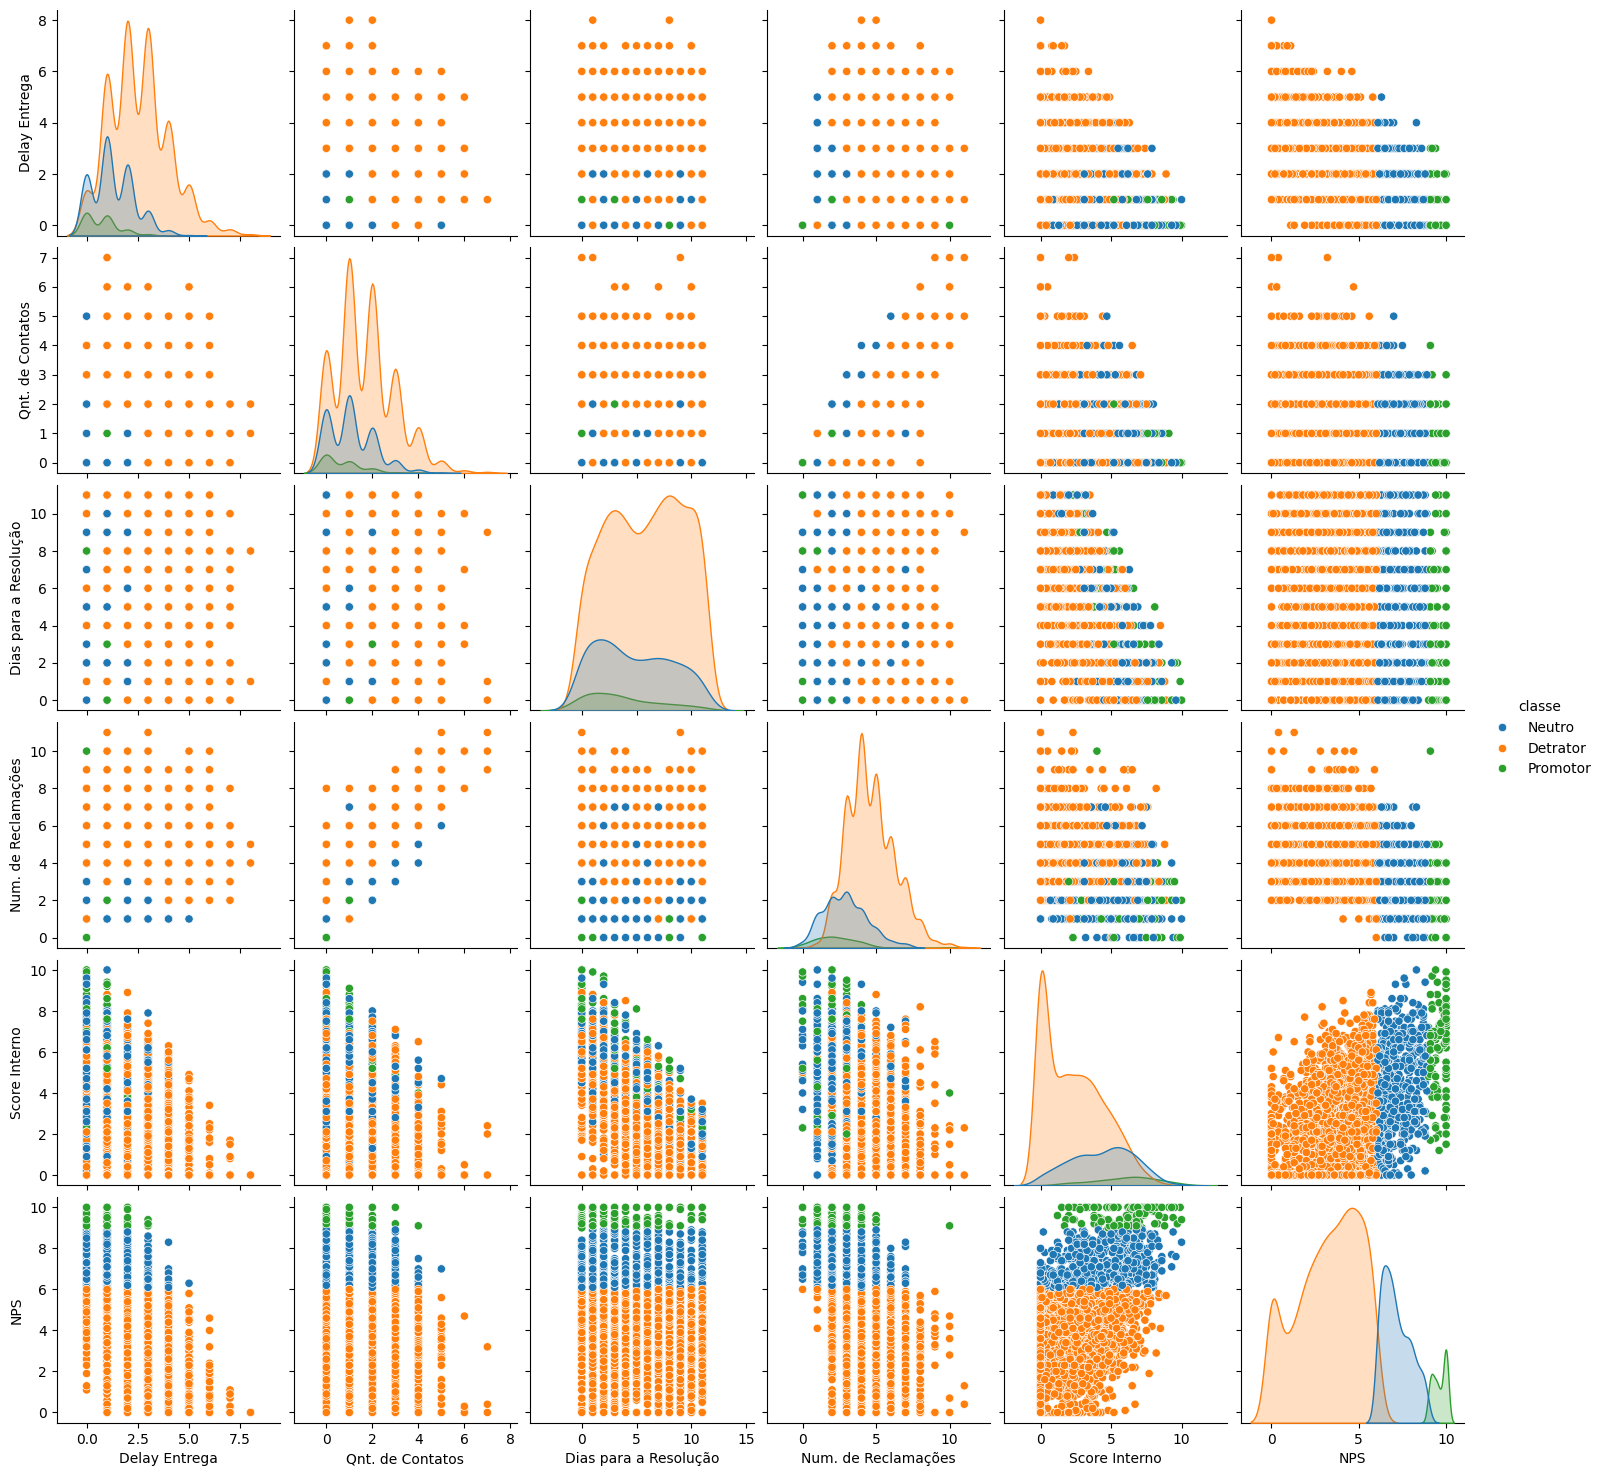

In [15]:
sns.pairplot(df_nps, hue='classe')

Vamos entender se a coluna que selecionamos tem correlações para entender melhor a nota baixa nop NPS

In [ ]:
sns.histplot(df_nps['NPS'], bins=30, kde=True)
plt.title('Distribuição do NPS')
plt.xlabel('NPS')
plt.ylabel('Frequência')
plt.show()

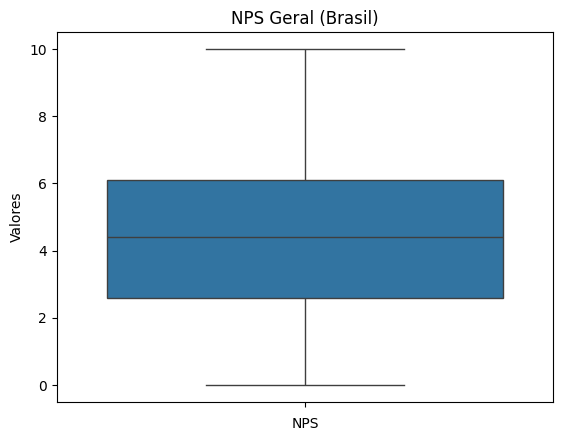

In [17]:
sns.boxplot(y=df_nps['NPS'])
#Adicionar título e rótulos
plt.title('NPS Geral (Brasil)')
plt.xlabel('NPS')
plt.ylabel('Valores')
plt.show()

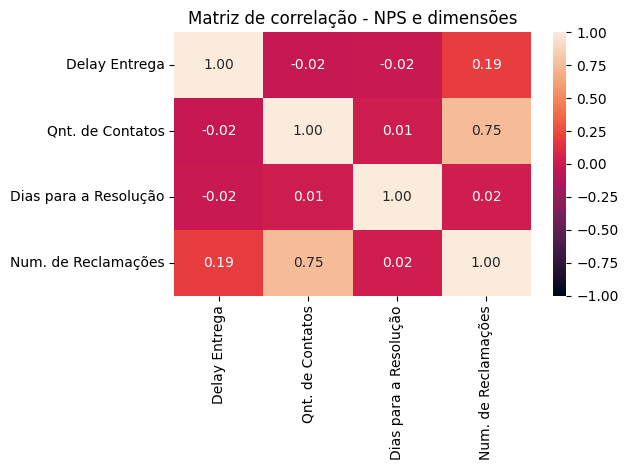

In [18]:
#Heatmap
colors_corr = [c for c in ['Delay Entrega', 'Qnt. de Contatos', 'Dias para a Resolução','Num. de Reclamações'] if c in df_nps.columns]
corr = df_nps[colors_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f" ,  cmap='rocket', vmin = -1, vmax = 1)
plt.title('Matriz de correlação - NPS e dimensões')
plt.tight_layout()
plt.show()

Aqui entendemos que há uma relação entre o número de contatos e a quantidade de reclamações, indicando que quando o cliente contata a empresa é para fazer uma reclamação. Isso pode prejudicar na nota do NPS.

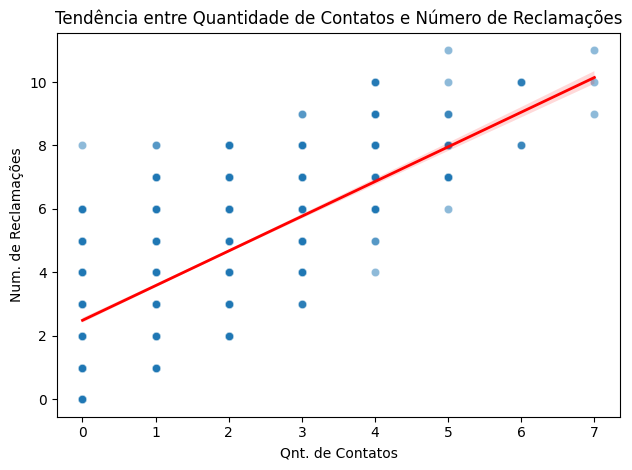

In [19]:
from pandas.core.tools.datetimes import Scalar
#Ver tendências
# se estamos comparando variáveis distintas, o quão tem uma tendencia de melhora ou piora ou o quão é acertivo o olhar
# primeira visão de regressão linear

sns.scatterplot(data = df_nps, x='Qnt. de Contatos', y='Num. de Reclamações', alpha = 0.5)

#linha de tendência com regplot
sns.regplot(
    data = df_nps,
    x='Qnt. de Contatos' ,
    y='Num. de Reclamações',
    scatter=False, # não recria os pontos
    color = 'red', # linha de tendencia em vermelho
    line_kws = {"linewidth": 2} # deixa a linha mais grossa
)

plt.title('Tendência entre Quantidade de Contatos e Número de Reclamações')
plt.xlabel('Qnt. de Contatos')
plt.ylabel('Num. de Reclamações')
plt.tight_layout()
plt.show()


In [ ]:
np.random.seed(42) #pega de forma aleatória resultados para fazer análise estatística
sample = df_nps.sample(n=1000, replace=False) #formula em que a gente define quantos dados vamos pegar e pedimos para não ter reposição
df.describe().round(2) #população
#gera estatisticas descritivas

In [21]:
sample.describe().round(2)

,Delay Entrega,Qnt. de Contatos,Dias para a Resolução,Num. de Reclamações,Score Interno,NPS
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2.20,1.53,5.36,4.15,3.00,4.42
std,1.45,1.20,3.47,1.75,2.39,2.51
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,2.00,3.00,0.80,2.60
50%,2.00,1.00,5.00,4.00,2.80,4.30
75%,3.00,2.00,8.00,5.00,4.80,6.20
max,8.00,7.00,11.00,11.00,10.00,10.00


In [22]:
#Estatisticas
sample_mean = sample['NPS'].mean() #média do NPS
sample_std = sample['NPS'].std(ddof=1) #desvio padrão amostral (=0 é da população)
n = len(sample)
sample_mean #média da amostra

np.float64(4.416799999999999)

<Axes: >

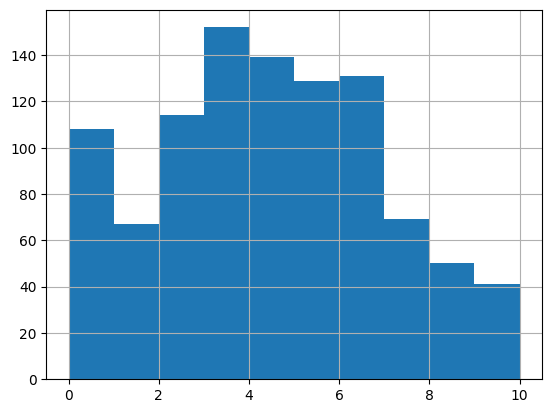

In [23]:
sample['NPS'].hist()

In [24]:
#Vamos confirmar que é uma distribuição normal
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

def analyze_distribution_and_ci(data, confidence=0.95, n_bootstrap=5000):#0.95 de confiança da estimativa
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)

    #Teste Shapiro Wilk para normalidade
    shapiro_stat, shapiro_p = shapiro(data)

    #Plot histograma
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(data, bins=10)
    plt.title('Histograma')

    #QQ-Plot
    plt.subplot(1,2,2)
    probplot(data, dist='norm', plot=plt)
    plt.title('QQ-Plot')

    plt.show()

    #Bootstrap CI
    alpha = 1 - confidence
    boot_means = []
    for _ in range(n_bootstrap):
      sample = np.random.choice(data, size=n, replace=True)
      boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, alpha/2 * 100)
    upper = np.percentile(boot_means, (1-alpha/2) * 100)
    ci_bootstrap = (lower, upper)

    print(f"Média da amostra: {mean:.3f}")
    print(f"IC Bootstrap ({confidence*100:.0f}%): {ci_bootstrap[0]:.3f} a {ci_bootstrap[1]:.3f}")
    print(f"p-valor shapiro-wilk: {shapiro_p:.4f} {'(nomral)'if shapiro_p>0.85 else '(não normal)'}")

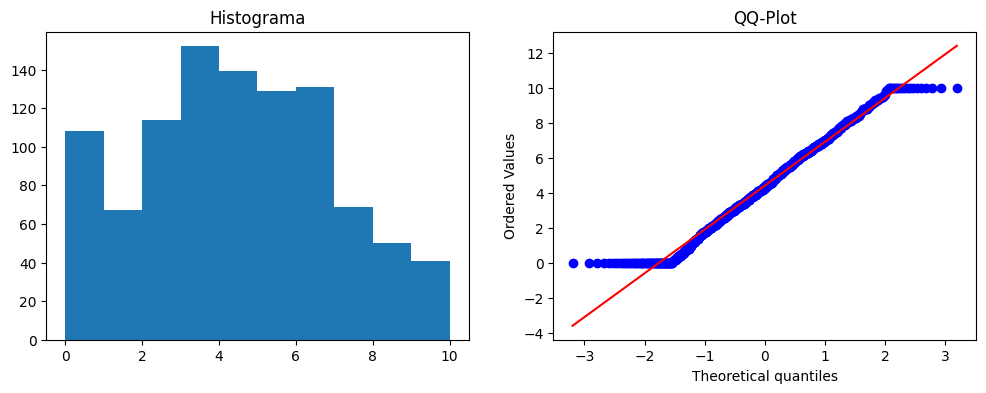

Média da amostra: 4.417
IC Bootstrap (95%): 4.259 a 4.570
p-valor shapiro-wilk: 0.0000 (não normal)


In [25]:
analyze_distribution_and_ci(sample['NPS'])

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def monthly_nps_ci(sample, confidence=0.95, n_bootstrap=5000):
    """
    Calcula a média de NPS e IC bootstrap por dias de atraso e plota um gráfico de linhas.
    """
    delays = sorted(sample['Delay Entrega'].unique())
    means = []
    lower_ci = []
    upper_ci = []

    alpha = 1 - confidence

    for delay in delays:
        data = sample.loc[sample['Delay Entrega'] == delay, 'NPS'].values
        n = len(data)
        mean = np.mean(data)

        # Bootstrap
        boot_means = []
        for _ in range(n_bootstrap):
            sample_boot = np.random.choice(data, size=n, replace=True)
            boot_means.append(np.mean(sample_boot))

        lower = np.percentile(boot_means, (alpha/2) * 100)
        upper = np.percentile(boot_means, (1 - alpha/2) * 100)

        means.append(mean)
        lower_ci.append(lower)
        upper_ci.append(upper)

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(delays, means, marker='o', label='Média NPS', color='blue')
    plt.fill_between(delays, lower_ci, upper_ci, color='lightblue', alpha=0.4, label=f'IC {int(confidence*100)}%')
    plt.title("Média de NPS por Dias de Delay com Intervalo de Confiança (Bootstrap)")
    plt.xlabel("Dias de Delay")
    plt.ylabel("NPS")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Retornar tabela resumo
    df_summary = pd.DataFrame({
        'Dias de Delay': delays,
        'Mean_NPS': means,
        'CI_lower': lower_ci,
        'CI_upper': upper_ci
    })

    return df_summary

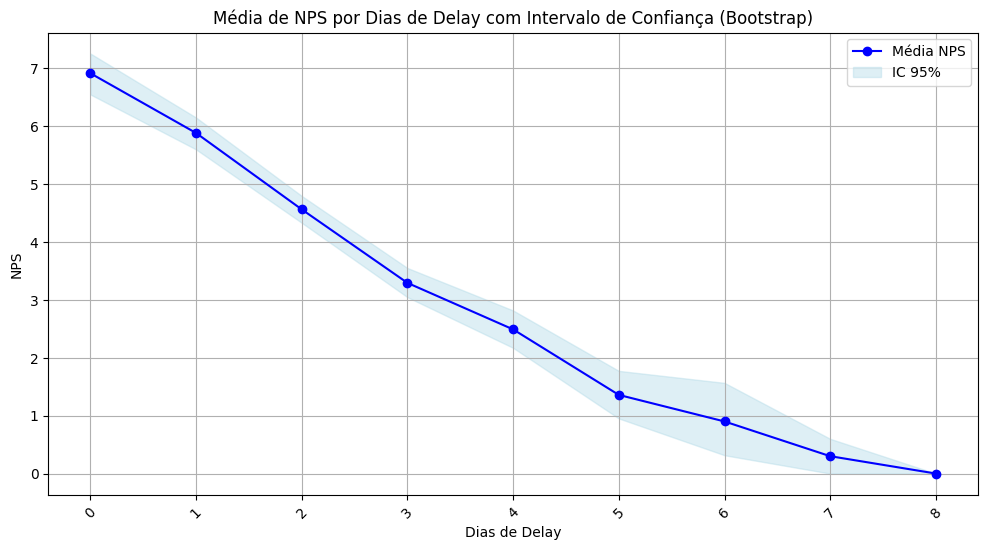

,Dias de Delay,Mean_NPS,CI_lower,CI_upper
0,0,6.916071,6.549978,7.257187
1,1,5.883750,5.600417,6.151250
2,2,4.563424,4.332296,4.796138
3,3,3.293868,3.047146,3.551415
4,4,2.490351,2.171930,2.817544
5,5,1.358696,0.952174,1.773913
6,6,0.900000,0.316667,1.566667
7,7,0.300000,0.000000,0.600000
8,8,0.000000,0.000000,0.000000


In [27]:
# Exemplo de uso:
df_summary = monthly_nps_ci(sample)
df_summary

Neste gráfico podemos entender que quanto maior o dia de delay na entrega, maior o nível de insatisfação do cliente. Podemos confirmar isso por conta do

##Vamos criar um novo df para analisar os dados por região <br/>
Vamos entender se por região o delay de entrega é maior, assim como as reclamações

In [41]:
df_regiao = pd.DataFrame(df.groupby('customer_region')[['delivery_delay_days', 'customer_service_contacts', 'resolution_time_days','complaints_count','nps_score']].mean().round(2)). reset_index()
df_regiao.columns = [ 'Regiao','Delay', 'Contatos', 'Resolucao','Reclamacoes', 'NPS']
df_regiao.head()

,Regiao,Delay,Contatos,Resolucao,Reclamacoes,NPS
0,Centro-Oeste,2.22,1.59,5.24,4.18,4.21
1,Nordeste,2.19,1.51,5.33,4.16,4.42
2,Norte,2.14,1.46,5.75,4.11,4.38
3,Sudeste,2.22,1.49,5.45,4.24,4.37
4,Sul,2.17,1.55,5.63,4.06,4.49


Vamos classificar o NPS em <br/>
- Promotor (9 a 10)
- Neutro (7 a 8)
- Detrator (0 a 6)


In [42]:
df_regiao['classe'] = df_regiao.apply(nps_class, axis=1)
df_regiao
#Fiz uma coluna qualitativa me indicando o grau do NPS

,Regiao,Delay,Contatos,Resolucao,Reclamacoes,NPS,classe
0,Centro-Oeste,2.22,1.59,5.24,4.18,4.21,Detrator
1,Nordeste,2.19,1.51,5.33,4.16,4.42,Detrator
2,Norte,2.14,1.46,5.75,4.11,4.38,Detrator
3,Sudeste,2.22,1.49,5.45,4.24,4.37,Detrator
4,Sul,2.17,1.55,5.63,4.06,4.49,Detrator


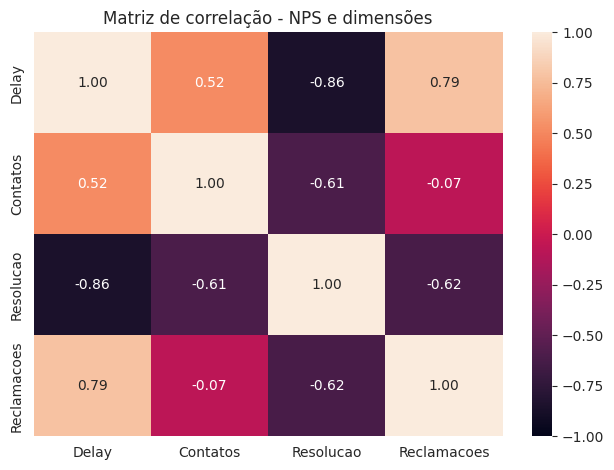

In [43]:
#Heatmap
colors_corr = [c for c in ['Delay', 'Contatos', 'Resolucao','Reclamacoes'] if c in df_regiao.columns]
corr = df_regiao[colors_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f" ,  cmap='rocket', vmin = -1, vmax = 1)
plt.title('Matriz de correlação - NPS e dimensões')
plt.tight_layout()
plt.show()

Com esse heatmap podemos criar uma hipotese de que quando o cliente faz alguma reclamação ou contata a empresa é referente ao delay da entrega

Vamos analisar a Região, onde nosso objetivo é entender se o delay da entrega está relacionado as regiões do país e quantas reclamações temos por região

In [58]:
df_regiao2 = df[['customer_region','delivery_delay_days', 'customer_service_contacts', 'resolution_time_days','complaints_count','nps_score']]
df_regiao2.columns = [ 'Regiao','Delay', 'Contatos', 'Resolucao','Reclamacoes', 'NPS']
df_regiao2.head()

,Regiao,Delay,Contatos,Resolucao,Reclamacoes,NPS
0,Nordeste,2,0,4,3,6.9
1,Sul,4,0,10,3,2.4
2,Nordeste,1,4,5,7,4.8
3,Centro-Oeste,2,1,11,4,5.9
4,Norte,1,1,0,3,6.1


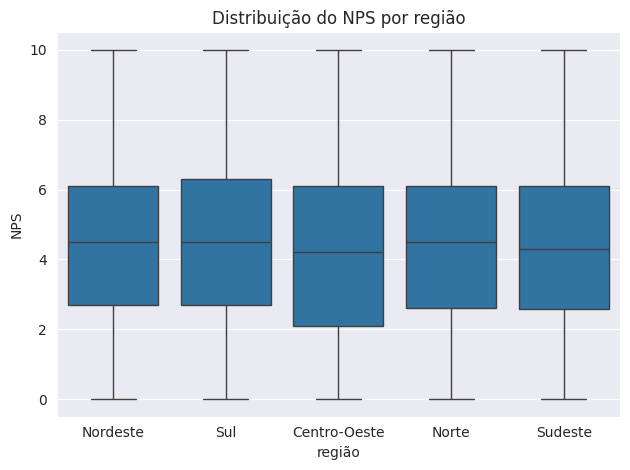

In [60]:
# Usando o seaborn para gráfico de boxplot
plt.figure()
sns.boxplot(y='NPS', x = 'Regiao', data=df_regiao2)
#Adicionar título e rótulos
plt.title('Distribuição do NPS por região')
plt.xlabel('região')
plt.ylabel('NPS')
plt.tight_layout()

plt.show()
#

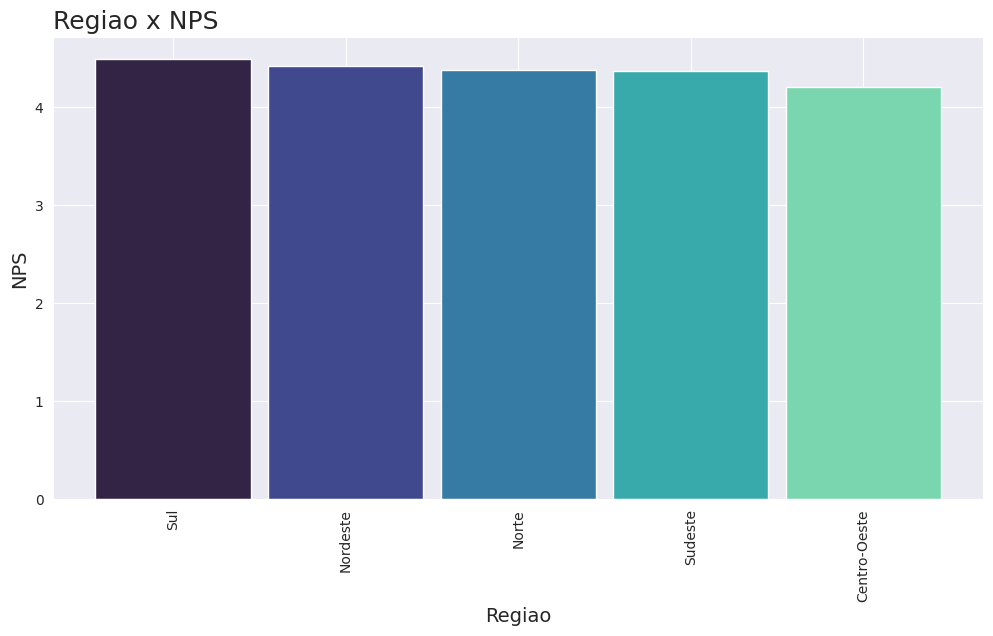

In [44]:
#Vamos analisar o Região x Delay
#Ordenando os valores
df_regiao = df_regiao.sort_values(by='NPS', ascending=False)
# Tamanho da figura
plt.figure(figsize=(12, 6))

#Paleta de cores
paleta_cores = sns.color_palette('mako', len(df_regiao))
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_regiao['Regiao'],
        df_regiao['NPS'],
        width=0.9,
        color = paleta_cores
        )
#Título
plt.title('Regiao x NPS', loc = 'left', fontsize=18)

#Labels
plt.xlabel('Regiao', fontsize = 14)
plt.ylabel('NPS', fontsize = 14)
plt.xticks(rotation=90);

##Conclusão

Não conseguimos chegar a uma conclusão de que a região do Brasil interfere na satisfação do cliente. Podemos concluir que realmente os maiores indicadores para uma nota ruim no NPS são o Delay na Entrega, as reclamações no site e o Número de contatos dos clientes.

## Gráficos para compor a Apresentação Executiva

Delay X NPS

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def monthly_nps_ci(sample, confidence=0.95, n_bootstrap=5000):
    """
    Calcula a média de NPS e IC bootstrap por dias de atraso e plota um gráfico de linhas.
    """
    delays = sorted(sample['Delay Entrega'].unique())
    means = []
    lower_ci = []
    upper_ci = []

    alpha = 1 - confidence

    for delay in delays:
        data = sample.loc[sample['Delay Entrega'] == delay, 'NPS'].values
        n = len(data)
        mean = np.mean(data)

        # Bootstrap
        boot_means = []
        for _ in range(n_bootstrap):
            sample_boot = np.random.choice(data, size=n, replace=True)
            boot_means.append(np.mean(sample_boot))

        lower = np.percentile(boot_means, (alpha/2) * 100)
        upper = np.percentile(boot_means, (1 - alpha/2) * 100)

        means.append(mean)
        lower_ci.append(lower)
        upper_ci.append(upper)

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(delays, means, marker='o', label='Média NPS', color='blue')
    plt.fill_between(delays, lower_ci, upper_ci, color='lightblue', alpha=0.4, label=f'IC {int(confidence*100)}%')
    plt.title("Média de NPS por Dias de Delay com Intervalo de Confiança (Bootstrap)")
    plt.xlabel("Dias de Delay")
    plt.ylabel("NPS")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Retornar tabela resumo
    df_summary = pd.DataFrame({
        'Dias de Delay': delays,
        'Mean_NPS': means,
        'CI_lower': lower_ci,
        'CI_upper': upper_ci
    })

    return df_summary

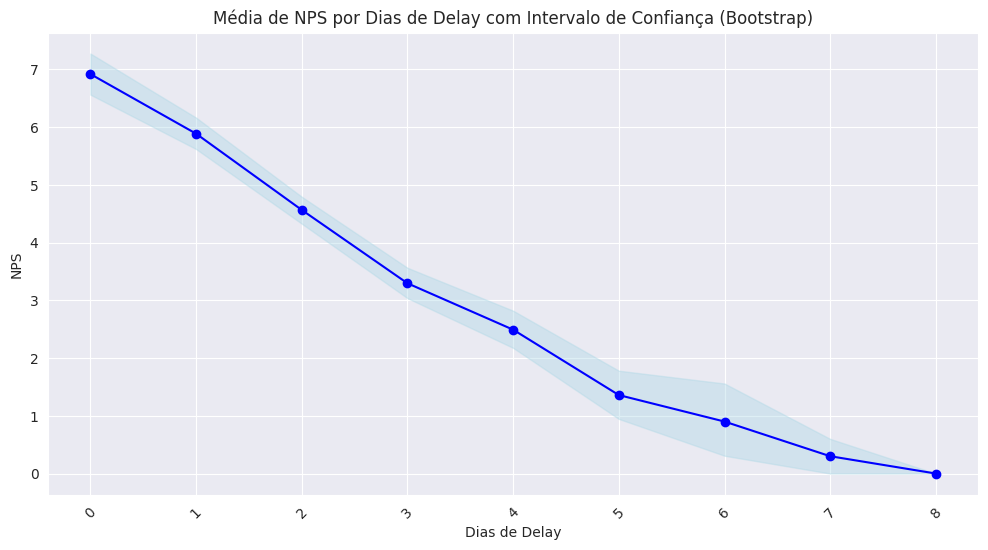

,Dias de Delay,Mean_NPS,CI_lower,CI_upper
0,0,6.916071,6.559799,7.271429
1,1,5.883750,5.617917,6.162083
2,2,4.563424,4.325282,4.791839
3,3,3.293868,3.036321,3.562300
4,4,2.490351,2.175417,2.819298
5,5,1.358696,0.945652,1.780435
6,6,0.900000,0.308333,1.558333
7,7,0.300000,0.000000,0.600000
8,8,0.000000,0.000000,0.000000


In [62]:
# Exemplo de uso:
df_summary = monthly_nps_ci(sample)
df_summary

NPS X Reclamações

In [ ]:
#['Delay Entrega', 'Qnt. de Contatos', 'Dias para a Resolução','Num. de Reclamações', 'Score Interno', 'NPS']

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def monthly_nps_ci(sample, confidence=0.95, n_bootstrap=5000):
    """
    Calcula a média de NPS e IC bootstrap por dias de atraso e plota um gráfico de linhas.
    """
    reclams = sorted(sample['Num. de Reclamações'].unique())
    means = []
    lower_ci = []
    upper_ci = []

    alpha = 1 - confidence

    for reclam in reclams:
        data = sample.loc[sample['Num. de Reclamações'] == reclam, 'NPS'].values
        n = len(data)
        mean = np.mean(data)

        # Bootstrap
        boot_means = []
        for _ in range(n_bootstrap):
            sample_boot = np.random.choice(data, size=n, replace=True)
            boot_means.append(np.mean(sample_boot))

        lower = np.percentile(boot_means, (alpha/2) * 100)
        upper = np.percentile(boot_means, (1 - alpha/2) * 100)

        means.append(mean)
        lower_ci.append(lower)
        upper_ci.append(upper)

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(reclams, means, marker='o', label='Média NPS', color='blue')
    plt.fill_between(reclams, lower_ci, upper_ci, color='lightblue', alpha=0.4, label=f'IC {int(confidence*100)}%')
    plt.title("Média de NPS por Número de Reclamações com Intervalo de Confiança (Bootstrap)")
    plt.xlabel("Número de Reclamações")
    plt.ylabel("NPS")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Retornar tabela resumo
    df_summary = pd.DataFrame({
        'Número de Reclamações': reclams,
        'Mean_NPS': means,
        'CI_lower': lower_ci,
        'CI_upper': upper_ci
    })

    return df_summary

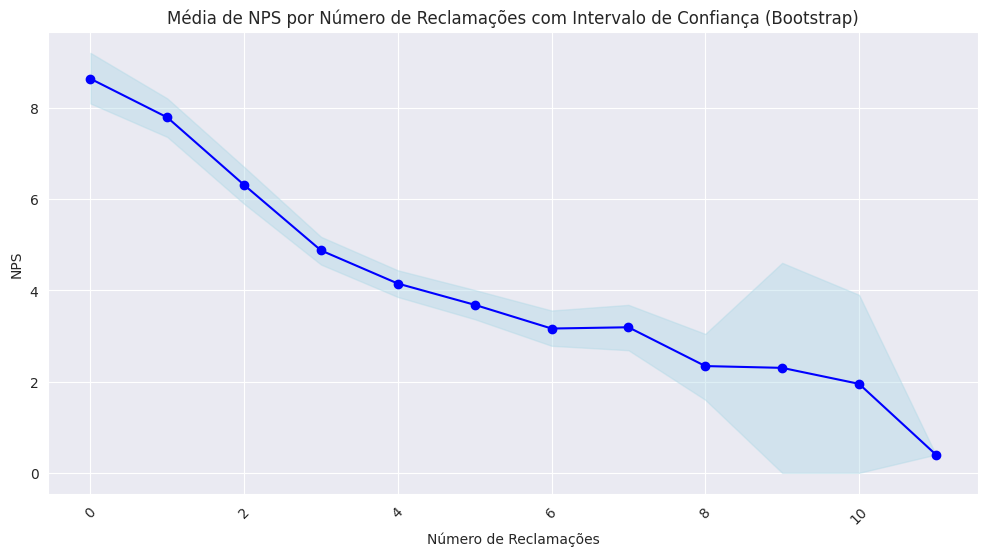

,Número de Reclamações,Mean_NPS,CI_lower,CI_upper
0,0,8.633333,8.091458,9.200000
1,1,7.786047,7.358081,8.202326
2,2,6.305769,5.893269,6.700024
3,3,4.872381,4.562845,5.170476
4,4,4.146311,3.852049,4.436516
5,5,3.681034,3.365517,4.005201
6,6,3.161468,2.783486,3.555986
7,7,3.189189,2.686486,3.679730
8,8,2.339130,1.600000,3.043478
9,9,2.300000,0.000000,4.600000


In [72]:
# Exemplo de uso:
df_summary = monthly_nps_ci(sample)
df_summary

Número de Contatos X Número de Reclamações

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def monthly_nps_ci(sample, confidence=0.95, n_bootstrap=5000):
    """
    Calcula a média de NPS e IC bootstrap por dias de atraso e plota um gráfico de linhas.
    """
    reclams = sorted(sample['Qnt. de Contatos'].unique())
    means = []
    lower_ci = []
    upper_ci = []

    alpha = 1 - confidence

    for reclam in reclams:
        data = sample.loc[sample['Qnt. de Contatos'] == reclam, 'Num. de Reclamações'].values
        n = len(data)
        mean = np.mean(data)

        # Bootstrap
        boot_means = []
        for _ in range(n_bootstrap):
            sample_boot = np.random.choice(data, size=n, replace=True)
            boot_means.append(np.mean(sample_boot))

        lower = np.percentile(boot_means, (alpha/2) * 100)
        upper = np.percentile(boot_means, (1 - alpha/2) * 100)

        means.append(mean)
        lower_ci.append(lower)
        upper_ci.append(upper)

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(reclams, means, marker='o', label='Média Num. de Reclam.', color='blue')
    plt.fill_between(reclams, lower_ci, upper_ci, color='lightblue', alpha=0.4, label=f'IC {int(confidence*100)}%')
    plt.title("Média de Número de Reclamações por Quantidade de Contatos com Intervalo de Confiança (Bootstrap)")
    plt.xlabel("Quantidade de Contatos")
    plt.ylabel("Número de Reclamações")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Retornar tabela resumo
    df_summary = pd.DataFrame({
        'Quantidade de Contatos': reclams,
        'Mean_NumRec': means,
        'CI_lower': lower_ci,
        'CI_upper': upper_ci
    })

    return df_summary

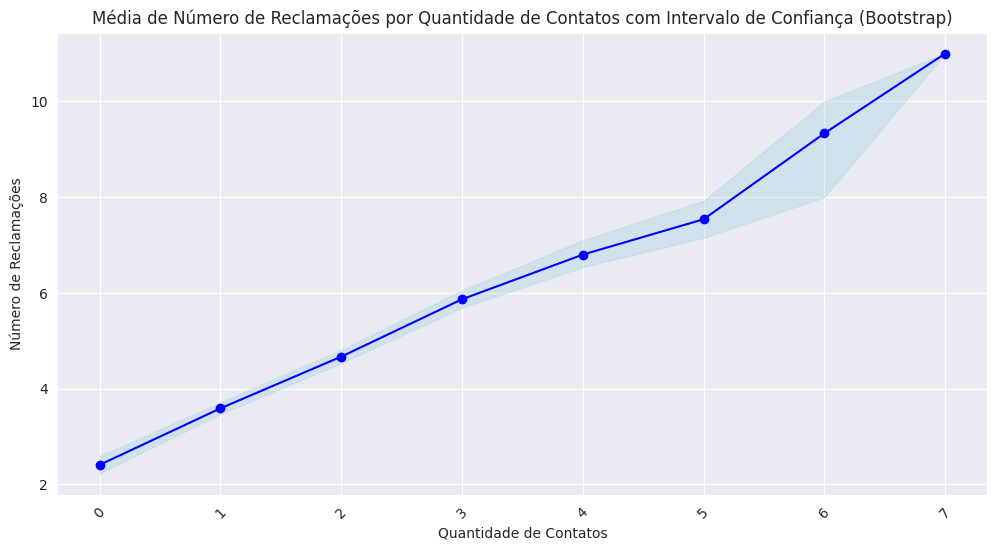

,Quantidade de Contatos,Mean_NumRec,CI_lower,CI_upper
0,0,2.409091,2.227273,2.590909
1,1,3.589744,3.472934,3.712251
2,2,4.669202,4.532319,4.809886
3,3,5.867769,5.694215,6.049587
4,4,6.800000,6.540000,7.100000
5,5,7.538462,7.153846,7.923077
6,6,9.333333,8.000000,10.000000
7,7,11.000000,11.000000,11.000000


In [74]:
# Exemplo de uso:
df_summary = monthly_nps_ci(sample)
df_summary

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def monthly_nps_ci(sample, confidence=0.95, n_bootstrap=5000):
    """
    Calcula a média de NPS e IC bootstrap por dias de atraso e plota um gráfico de linhas.
    """
    reclams = sorted(sample['complaints_count'].unique())
    means = []
    lower_ci = []
    upper_ci = []

    alpha = 1 - confidence

    for reclam in reclams:
        data = sample.loc[sample['complaints_count'] == reclam, 'repeat_purchase_30d'].values
        n = len(data)
        mean = np.mean(data)

        # Bootstrap
        boot_means = []
        for _ in range(n_bootstrap):
            sample_boot = np.random.choice(data, size=n, replace=True)
            boot_means.append(np.mean(sample_boot))

        lower = np.percentile(boot_means, (alpha/2) * 100)
        upper = np.percentile(boot_means, (1 - alpha/2) * 100)

        means.append(mean)
        lower_ci.append(lower)
        upper_ci.append(upper)

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(reclams, means, marker='o', label='Média Num. de Reclam.', color='blue')
    plt.fill_between(reclams, lower_ci, upper_ci, color='lightblue', alpha=0.4, label=f'IC {int(confidence*100)}%')
    plt.title("Média de Comprou de novo por Número de Reclamações com Intervalo de Confiança (Bootstrap)")
    plt.xlabel("Número de Reclamações")
    plt.ylabel("Comprou de novo")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Retornar tabela resumo
    df_summary = pd.DataFrame({
        'Número de Reclamações': reclams,
        'Mean_NumRec': means,
        'CI_lower': lower_ci,
        'CI_upper': upper_ci
    })

    return df_summary

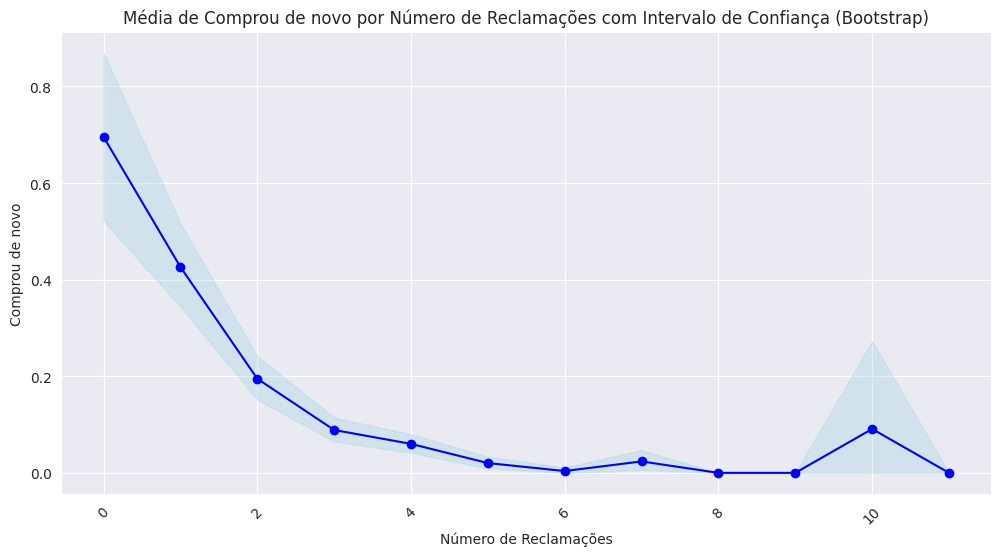

,Número de Reclamações,Mean_NumRec,CI_lower,CI_upper
0,0,0.695652,0.521739,0.869565
1,1,0.426230,0.344262,0.516393
2,2,0.194946,0.151625,0.241877
3,3,0.088757,0.065089,0.114398
4,4,0.060000,0.041667,0.080000
5,5,0.020270,0.009009,0.033784
6,6,0.003759,0.000000,0.011278
7,7,0.023669,0.005917,0.047337
8,8,0.000000,0.000000,0.000000
9,9,0.000000,0.000000,0.000000


In [161]:
df_summary = monthly_nps_ci(df)
df_summary

##Entendendo o cliente

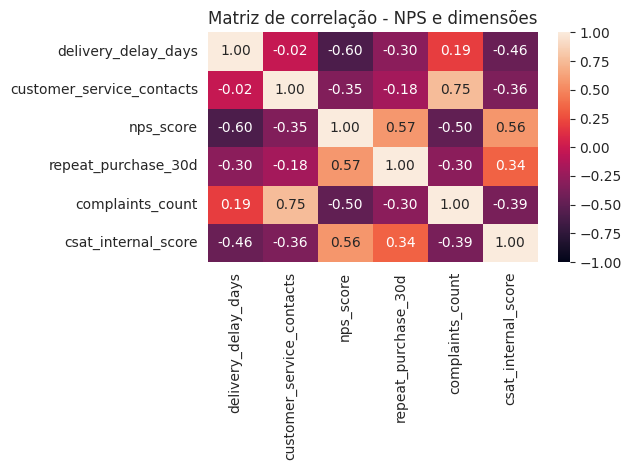

In [ ]:
#Heatmap
colors_corr = [c for c in ['delivery_delay_days','customer_service_contacts','nps_score','repeat_purchase_30d','complaints_count','csat_internal_score'] if c in df.columns]
corr = df[colors_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f" ,  cmap='rocket', vmin = -1, vmax = 1)
plt.title('Matriz de correlação - NPS e dimensões')
plt.tight_layout()
plt.show()

Aqui temos que um maior fator de notas no NPS está ligado ao atendimento, ou seja, clientes que contatam a empresa e tem um atendimento satifatório tende a melhorar a nota do NPS

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def monthly_nps_ci(sample, confidence=0.95, n_bootstrap=5000):
    """
    Calcula a média de NPS e IC bootstrap por dias de atraso e plota um gráfico de linhas.
    """
    reclams = sorted(sample['csat_internal_score'].unique())
    means = []
    lower_ci = []
    upper_ci = []

    alpha = 1 - confidence

    for reclam in reclams:
        data = sample.loc[sample['csat_internal_score'] == reclam, 'nps_score'].values
        n = len(data)
        mean = np.mean(data)

        # Bootstrap
        boot_means = []
        for _ in range(n_bootstrap):
            sample_boot = np.random.choice(data, size=n, replace=True)
            boot_means.append(np.mean(sample_boot))

        lower = np.percentile(boot_means, (alpha/2) * 100)
        upper = np.percentile(boot_means, (1 - alpha/2) * 100)

        means.append(mean)
        lower_ci.append(lower)
        upper_ci.append(upper)

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(reclams, means, marker='o', label='Média Num. de Reclam.', color='blue')
    plt.fill_between(reclams, lower_ci, upper_ci, color='lightblue', alpha=0.4, label=f'IC {int(confidence*100)}%')
    plt.title("Média de NPS por Nota de atendimento com Intervalo de Confiança (Bootstrap)")
    plt.xlabel("Nota de atendimento")
    plt.ylabel("NPS")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Retornar tabela resumo
    df_summary = pd.DataFrame({
        'Nota de atendimento': reclams,
        'Mean_NumRec': means,
        'CI_lower': lower_ci,
        'CI_upper': upper_ci
    })

    return df_summary

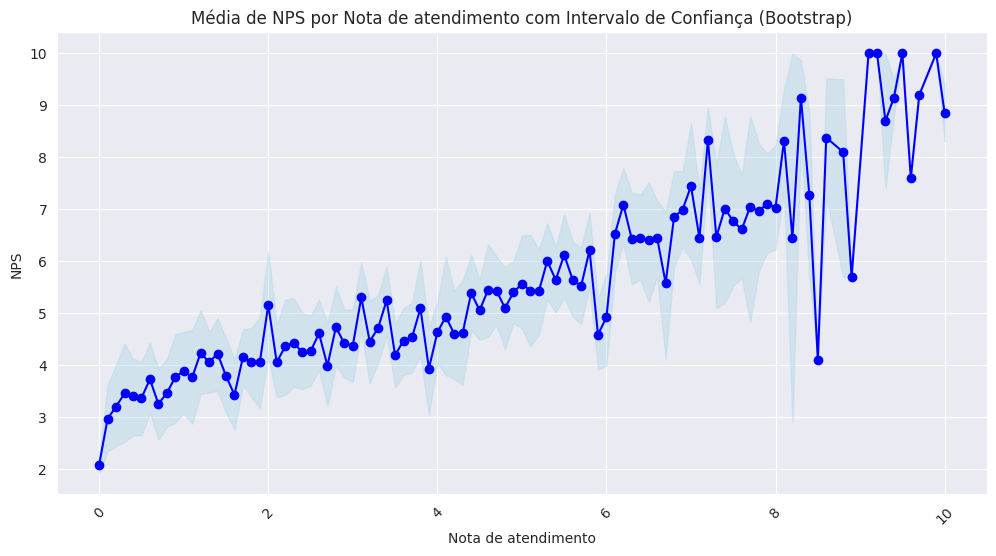

,Nota de atendimento,Mean_NumRec,CI_lower,CI_upper
0,0.0,2.088095,1.918398,2.263225
1,0.1,2.969697,2.345455,3.627348
2,0.2,3.203704,2.440648,4.007407
3,0.3,3.455556,2.522222,4.416667
4,0.4,3.400000,2.650000,4.125125
...,...,...,...,...
93,9.5,10.000000,10.000000,10.000000
94,9.6,7.600000,7.600000,7.600000
95,9.7,9.200000,9.200000,9.200000
96,9.9,10.000000,10.000000,10.000000


In [139]:
df_summary = monthly_nps_ci(df)
df_summary

In [141]:
df_cliente = df[['delivery_delay_days', 'customer_service_contacts','complaints_count','repeat_purchase_30d','nps_score', 'csat_internal_score']]
df_cliente.columns = ['Delay', 'Contatos','Reclamacoes','Comprou DNV', 'NPS', "CSAT"]
df_cliente.head()

,Delay,Contatos,Reclamacoes,Comprou DNV,NPS,CSAT
0,2,0,3,0,6.9,6.5
1,4,0,3,0,2.4,0.0
2,1,4,7,0,4.8,1.5
3,2,1,4,0,5.9,0.3
4,1,1,3,0,6.1,7.9


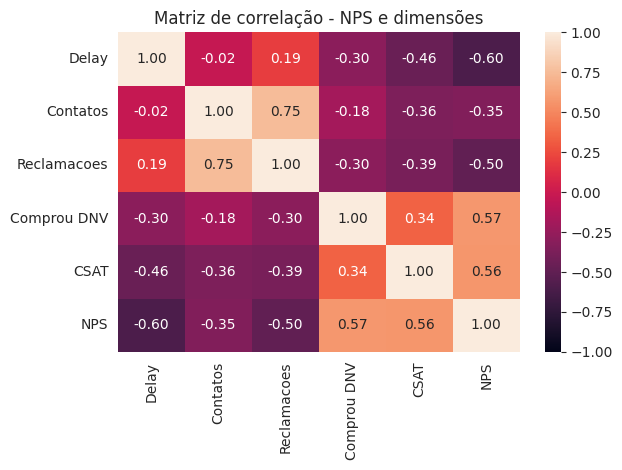

In [157]:
#Heatmap
colors_corr = [c for c in ['Delay', 'Contatos', 'Resolucao','Reclamacoes','Comprou DNV','CSAT', 'NPS'] if c in df_cliente.columns]
corr = df_cliente[colors_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f" ,  cmap='rocket', vmin = -1, vmax = 1)
plt.title('Matriz de correlação - NPS e dimensões')
plt.tight_layout()
plt.show()